## Evaluation & Comparison

Workflow:
1. Summarize best results from binary classification (notebook 04)
2. Summarize best results from multiclass classification (notebook 05)
3. Compare binary vs multiclass performance
4. Discuss feature importance of the best models
5. Final conclusions

In [1]:
# 1. Summarize best results from binary classification (notebook 04)

import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

random_state = 42

# Load data
X_train_bin = pd.read_parquet("../data/reduced/X_train_kbest_label.parquet")
X_test_bin = pd.read_parquet("../data/reduced/X_test_kbest_label.parquet")
y_train_bin = pd.read_parquet("../data/processed/y_label_train.parquet")['label']
y_test_bin = pd.read_parquet("../data/processed/y_label_test.parquet")['label']

best_model_binary = RandomForestClassifier(
    random_state=random_state,
    n_estimators=50, 
    max_depth=15,
    class_weight=None
)
best_model_binary.fit(X_train_bin, y_train_bin)

y_pred_bin = best_model_binary.predict(X_test_bin)
f1_binary = f1_score(y_test_bin, y_pred_bin)

print("Best binary model (from notebook 4):")
print(classification_report(y_test_bin, y_pred_bin, zero_division=0))
print(f"F1: {f1_binary:.3f}")

Best binary model (from notebook 4):
              precision    recall  f1-score   support

           0       0.96      0.88      0.92     16135
           1       0.88      0.96      0.92     15817

    accuracy                           0.92     31952
   macro avg       0.92      0.92      0.92     31952
weighted avg       0.92      0.92      0.92     31952

F1: 0.922


In [2]:
# 2. Summarize best results from multiclass classification (notebook 05)

X_train_multi = pd.read_parquet("../data/reduced/X_train_kbest_cat.parquet")
X_test_multi = pd.read_parquet("../data/reduced/X_test_kbest_cat.parquet")
y_train_multi = pd.read_parquet("../data/processed/y_cat_train.parquet")['attack_cat']
y_test_multi = pd.read_parquet("../data/processed/y_cat_test.parquet")['attack_cat']

best_model_multi = RandomForestClassifier(
    random_state=random_state,
    n_estimators=50, 
    max_depth=15,
    class_weight="balanced"
)
best_model_multi.fit(X_train_multi, y_train_multi)

y_pred_multi = best_model_multi.predict(X_test_multi)
f1_multi = f1_score(y_test_multi, y_pred_multi, average='macro')

print("Best multiclass model (from notebook 5):")
print(classification_report(y_test_multi, y_pred_multi, zero_division=0))
print(f"Macro F1: {f1_multi:.3f}")

Best multiclass model (from notebook 5):
                precision    recall  f1-score   support

      Analysis       0.15      0.60      0.24       362
      Backdoor       0.19      0.36      0.25       408
           DoS       0.38      0.25      0.30      1044
      Exploits       0.87      0.76      0.81      6394
       Fuzzers       0.60      0.83      0.70      4718
       Generic       0.83      0.66      0.73       584
        Normal       1.00      0.82      0.90     16135
Reconnaissance       0.75      0.82      0.78      1962
     Shellcode       0.24      0.85      0.38       299
         Worms       0.55      0.57      0.56        46

      accuracy                           0.78     31952
     macro avg       0.56      0.65      0.57     31952
  weighted avg       0.85      0.78      0.80     31952

Macro F1: 0.566


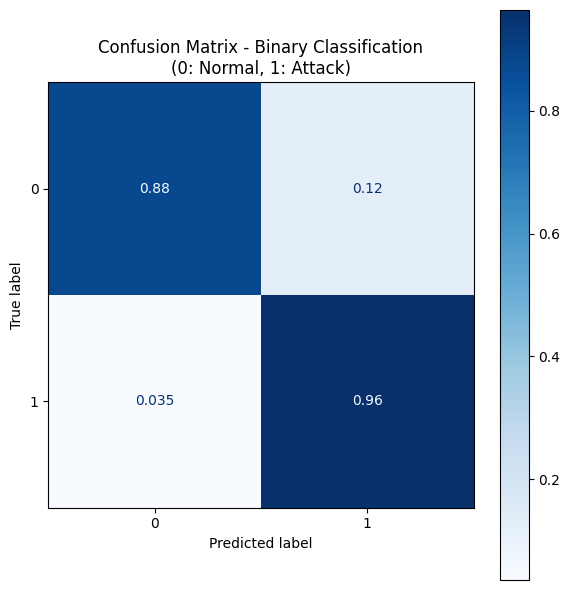

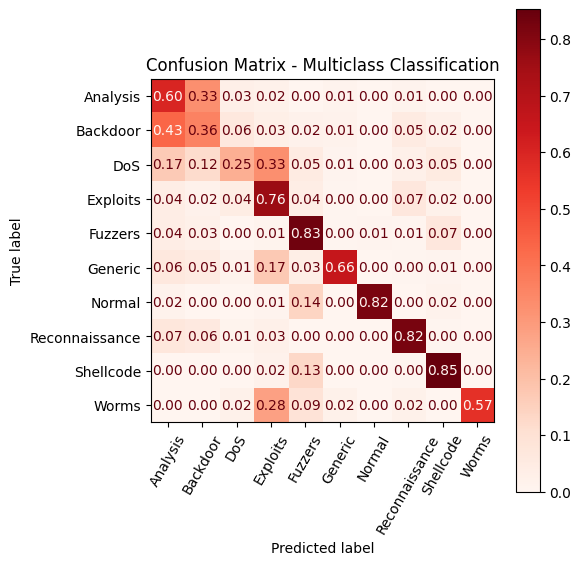

In [3]:
# 3. Compare binary vs multiclass performance

import os
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

#Binary confusion matrix

os.makedirs("../doc/images", exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_bin, y_pred_bin, normalize='true', cmap='Blues', ax=ax
)
ax.set_title("Confusion Matrix - Binary Classification\n(0: Normal, 1: Attack)")
plt.tight_layout()
plt.savefig("../doc/images/cm_binary.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Multiclass confusion matrix
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_multi, y_pred_multi, normalize='true', cmap='Reds',
    ax=ax, xticks_rotation=60, values_format='.2f'
)
ax.set_title("Confusion Matrix - Multiclass Classification")
plt.tight_layout()
plt.savefig("../doc/images/cm_multiclass.pdf", format="pdf", bbox_inches="tight")
plt.show()

### Confusion Matrix discussion

The binary model shows a favorable pattern for an intrusion detection context: attack
recall (96%) is higher than normal-traffic recall (88%), meaning very few real attacks
go undetected (3.5% false negative rate) at the cost of some false positives (12%), a
reasonable trade-off given the higher cost of missed attacks in a cybersecurity context.

Talking about the multiclass confusion matrix, misclassification is not random but
concentrated among specific category pairs: Backdoor is most often confused with
Analysis (43%), DoS with Exploits (33%), and Worms with Exploits (28%), all minority
classes with overlapping traffic characteristics and limited training examples. Normal
traffic is also confused with Fuzzers in 14% of cases — notably, this confusion cannot
be explained by class imbalance alone, since Normal is the majority class (56,000 examples
in the training set). This suggests genuine overlap between some fuzzing traffic and
normal traffic behaviour, supporting the conclusion that the limited macro F1 (0.57)
reflects real classification difficulty rather than insufficient training data or a
modeling flaw.

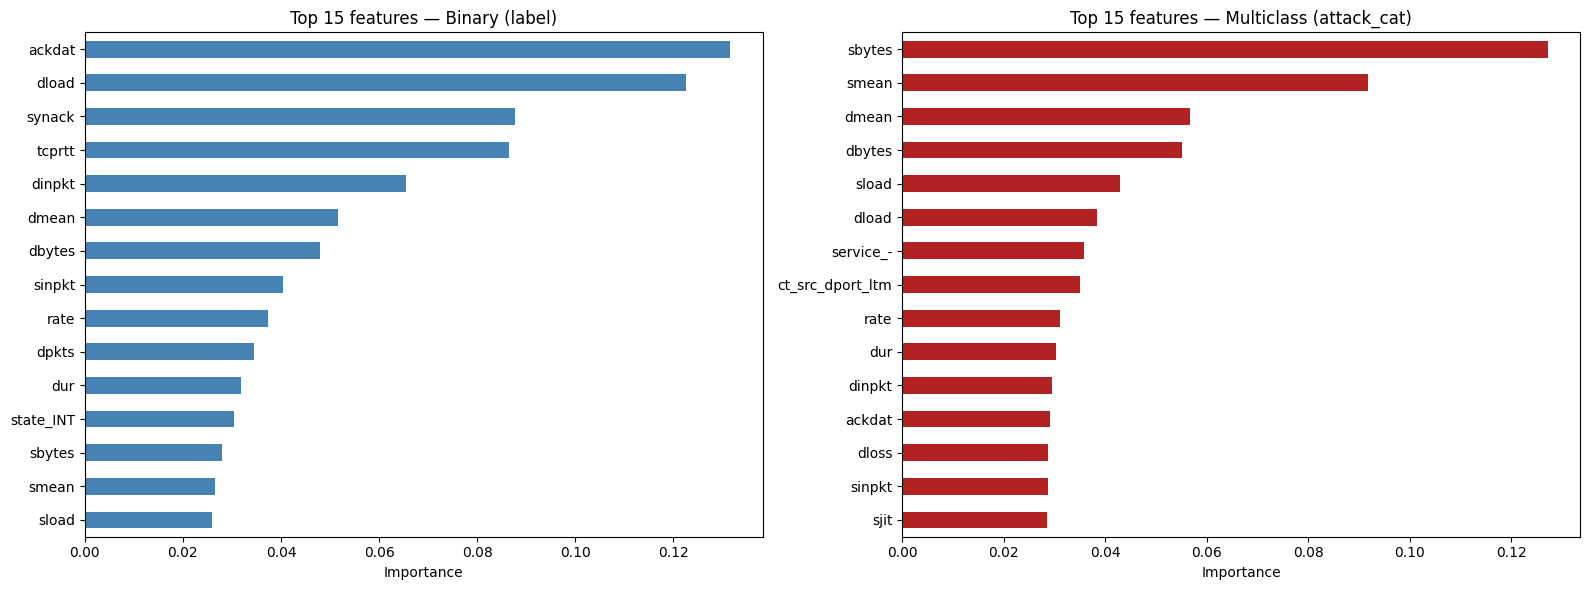

In [4]:
# 4. Discuss feature importance of the best models

import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Binary model feature importance
importance_bin = pd.Series(
    best_model_binary.feature_importances_,
    index=X_train_bin.columns
).sort_values(ascending=False).head(15)

importance_bin.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title("Top 15 features — Binary (label)")
axes[0].set_xlabel("Importance")

# Multiclass model feature importance
importance_multi = pd.Series(
    best_model_multi.feature_importances_,
    index=X_train_multi.columns
).sort_values(ascending=False).head(15)

importance_multi.plot(kind='barh', ax=axes[1], color='firebrick')
axes[1].invert_yaxis()
axes[1].set_title("Top 15 features — Multiclass (attack_cat)")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("../doc/images/feature_importance.pdf", format="pdf", bbox_inches="tight")
plt.show()

### Feature importance discussion

11 of the top 15 features are shared between the binary and multiclass models,
indicating consistent underlying signal. The main difference is that the binary model
relies more on TCP handshake timing features (ackdat, synack, tcprtt), since anomalous
handshakes are a strong indicator of malicious traffic. The multiclass model instead
relies more heavily on byte-transfer volume features (sbytes, smean, dmean, dbytes),
which is intuitive since different attack categories (e.g. DoS or Exploits) typically
produce different traffic volume patterns, useful to pinpoint the specific attack type
rather than only detecting its presence.

In [5]:
# 5. Final conclusions

summary = pd.DataFrame({
    'Task': ['Binary (label)', 'Multiclass (attack_cat)'],
    'Best model': [best_model_binary, best_model_multi],
    'Metric': ['F1', 'Macro F1'],
    'Score': [f1_binary, f1_multi]
})

display(summary.style.format({'Score': '{:.3f}'}).set_caption('Final results summary'))

,Task,Best model,Metric,Score
0,Binary (label),"RandomForestClassifier(max_depth=15, n_estimators=50, random_state=42)",F1,0.922
1,Multiclass (attack_cat),"RandomForestClassifier(class_weight='balanced', max_depth=15, n_estimators=50, random_state=42)",Macro F1,0.566


### Final conclusions

This project explored intrusion detection through two complementary tasks: binary classification (normal vs attack) and multiclass classification (attack category). Random Forest achieved better results on both tasks, using features selected via SelectKBest (50 features of 185 total).

The binary model performed strongly (F1 = 0.92), with an error profile favorable for security applications. The multiclass task proved to be substantially harder (macro F1 = 0.57), reflecting overlap between several attack categories and, for the rarest classes, the limited number of training examples available.

PCA was also explored as an alternative dimensionality reduction technique (notebook 03), but excluded later on (notebook 04) due to impractical computation time during grid search. SMOTE was considered as a way to address the multiclass imbalance, but was also excluded for computational reasons.

This project demonstrates that traffic timing and byte-volume statistics are strong indicators of malicious network activity, though distinguishing between specific attack types proved challenging for rare categories.